# MVP: Qualidade de Software, Segurança e Sistemas Inteligentes

## 1. Definição do problema

Neste projeto, será desenvolvido um modelo de machine learning para um problema de classificação multiclasse.
**O objetivo é identificar a variedade de um grão de feijão com base em características físicas extraídas de cada amostra, como área, perímetro, comprimento, largura e medidas relacionadas ao formato.**

O dataset escolhido foi o **Dry Bean Dataset, disponível no UCI Machine Learning Repository.** A variável alvo do problema é a coluna `Class`, que indica a variedade do feijão. As demais colunas do conjunto de dados representam os atributos de entrada utilizados para treinar os modelos de classificação.

Por se tratar de um problema de classificação supervisionada com múltiplas classes e atributos numéricos, esse dataset é adequado para a aplicação de algoritmos clássicos de machine learning, como KNN, Árvore de Classificação, Naive Bayes e SVM.

## 2. Importação das bibliotecas

Nesta etapa, são importadas apenas as bibliotecas necessárias para a execução do projeto.

A biblioteca `pandas` será utilizada para carregar e manipular os dados em formato tabular. As bibliotecas `matplotlib` e `seaborn` serão utilizadas para a visualização gráfica das informações e dos resultados obtidos.

A biblioteca principal do projeto é a `Scikit-Learn`, que será utilizada para separar os dados em treino e teste, criar pipelines de pré-processamento, treinar os algoritmos de classificação exigidos no trabalho, otimizar hiperparâmetros e avaliar o desempenho dos modelos.

Por fim, a biblioteca `joblib` será usada para exportar o modelo final treinado, permitindo sua utilização posterior na aplicação full stack.


In [ ]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualizaçao
import matplotlib.pyplot as plt
import seaborn as sns

# Divisão dos dados e otimização de hiperparâmetros
from sklearn.model_selection import train_test_split, GridSearchCV

# Pipeline e padronização
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Algoritmos de classificação
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Exportação do modelo
import joblib

## 3. Carga do dataset

Nesta etapa, o dataset será carregado diretamente a partir de uma URL pública do repositório UCI Machine Learning Repository, sem a necessidade de arquivos locais. Essa abordagem facilita a reprodutibilidade do projeto, permitindo que o notebook seja executado do início ao fim no Google Colab.

O conjunto de dados utilizado é o **Dry Bean Dataset**, composto por 13.611 registros, 16 atributos preditores numéricos e uma variável alvo chamada `Class`, que representa a variedade do feijão.


In [ ]:
from io import BytesIO
from zipfile import ZipFile
import requests

# URL pública do dataset na UCI
dataset_url = (
    "https://archive.ics.uci.edu/"
    "static/public/602/dry+bean+dataset.zip"
)

# Download do arquivo compactado
response = requests.get(dataset_url)
response.raise_for_status()

# Extração do arquivo Excel contido no .zip
with ZipFile(BytesIO(response.content)) as zip_file:
    with zip_file.open(
        "DryBeanDataset/Dry_Bean_Dataset.xlsx"
    ) as dataset_file:
        df = pd.read_excel(dataset_file)

# Visualização inicial
print("Dimensões do dataset:", df.shape)
df.head()


## 4. Análise inicial dos dados

Após a carga do dataset, é importante realizar uma análise inicial para compreender sua estrutura, verificar os tipos de dados presentes, identificar possíveis valores ausentes e observar a distribuição da variável alvo.

Essa etapa é fundamental para garantir que os dados estejam adequados para o treinamento dos modelos de machine learning e para apoiar as decisões de pré-processamento e modelagem.


In [ ]:
# Informações gerais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [ ]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [ ]:
# Verificação de valores ausentes
df.isnull().sum()

,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [ ]:
# Distribuição das classes
df["Class"].value_counts()

,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


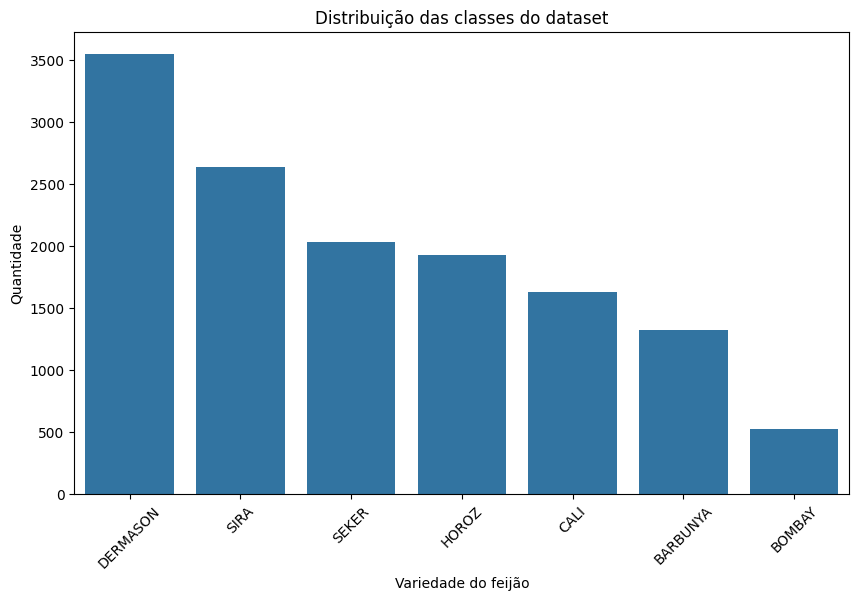

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Class", order=df["Class"].value_counts().index)
plt.title("Distribuição das classes do dataset")
plt.xlabel("Variedade do feijão")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.show()

## 5. Separação entre treino e teste

Nesta etapa, os dados serão separados em conjuntos de treino e teste por meio da estratégia holdout. O conjunto de treino será utilizado para o treinamento e ajuste dos modelos, enquanto o conjunto de teste será reservado para a avaliação final do desempenho.

Como a variável alvo possui múltiplas classes e distribuição não totalmente uniforme, será utilizada a estratificação (`stratify`) para preservar, de forma proporcional, a distribuição das classes nos dois subconjuntos.


In [ ]:
# Separação entre variáveis de entrada e variável alvo
X = df.drop("Class", axis=1)
y = df["Class"]

# Divisão em treino e teste com holdout
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Dimensão de X_train:", X_train.shape)
print("Dimensão de X_test:", X_test.shape)
print("Dimensão de y_train:", y_train.shape)
print("Dimensão de y_test:", y_test.shape)

Dimensão de X_train: (10888, 16)
Dimensão de X_test: (2723, 16)
Dimensão de y_train: (10888,)
Dimensão de y_test: (2723,)


In [ ]:
print("Distribuição das classes no conjunto de treino:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribuição das classes no conjunto de teste:")
print(y_test.value_counts(normalize=True).sort_index())

Distribuição das classes no conjunto de treino:
Class
BARBUNYA    0.097079
BOMBAY      0.038391
CALI        0.119765
DERMASON    0.260562
HOROZ       0.141624
SEKER       0.148880
SIRA        0.193699
Name: proportion, dtype: float64

Distribuição das classes no conjunto de teste:
Class
BARBUNYA    0.097319
BOMBAY      0.038193
CALI        0.119721
DERMASON    0.260375
HOROZ       0.141755
SEKER       0.149100
SIRA        0.193537
Name: proportion, dtype: float64


## 6. Pré-processamento dos dados e definição dos modelos

Como o dataset é formado por variáveis numéricas com escalas diferentes, serão consideradas duas abordagens de transformação dos dados: a normalização e a padronização.

A normalização será representada pelo `MinMaxScaler`, que ajusta os valores para uma faixa comum. Já a padronização será realizada com o `StandardScaler`, que transforma os dados para que tenham média próxima de zero e desvio padrão próximo de um.

Essas etapas são especialmente importantes para algoritmos sensíveis à escala dos atributos, como KNN e SVM.

Além disso, serão utilizados `pipelines` para organizar o fluxo de pré-processamento e treinamento dos modelos. Essa abordagem contribui para um código mais limpo, reduz a chance de erros e segue boas práticas de implementação.

Nesta etapa, também serão definidos os quatro algoritmos exigidos pelo trabalho: KNN, Árvore de Classificação, Naive Bayes e SVM.


In [16]:
# Definição dos pipelines para cada algoritmo
pipelines = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(random_state=42))
    ])
}

### 6.1 Comparação entre normalização e padronização

Como o enunciado do projeto exige a consideração de normalização e padronização, será feita uma comparação inicial entre essas duas abordagens nos modelos mais sensíveis à escala dos dados, especialmente KNN e SVM.

O objetivo dessa etapa é observar qual transformação produz melhor desempenho no conjunto de teste e, a partir disso, definir a estratégia de pré-processamento a ser mantida no restante do experimento.


In [31]:
scaling_comparison = []

scaling_options = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler()
}

models_to_compare = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=42)
}

for scaler_name, scaler in scaling_options.items():
    for model_name, model in models_to_compare.items():
        pipeline = Pipeline([
            ("scaler", scaler),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        scaling_comparison.append({
            "Transformação": scaler_name,
            "Modelo": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1-Score Macro": f1_score(y_test, y_pred, average="macro")
        })

scaling_results_df = pd.DataFrame(scaling_comparison)
scaling_results_df = scaling_results_df.sort_values(
    by="F1-Score Macro",
    ascending=False
).reset_index(drop=True)

scaling_results_df.style.format({
    "Accuracy": "{:.4f}",
    "F1-Score Macro": "{:.4f}"
})

,Transformação,Modelo,Accuracy,F1-Score Macro
0,StandardScaler,SVM,0.9221,0.9343
1,MinMaxScaler,SVM,0.9207,0.9321
2,StandardScaler,KNN,0.9166,0.9293
3,MinMaxScaler,KNN,0.9126,0.9269


A comparação entre normalização e padronização mostrou que a padronização com `StandardScaler` apresentou melhor desempenho nos modelos avaliados, especialmente no SVM. Por esse motivo, a padronização foi mantida como estratégia principal de pré-processamento nas etapas seguintes do projeto.


## 7. Treinamento inicial e comparação dos modelos

Nesta etapa, os modelos definidos anteriormente serão treinados com o conjunto de treino e avaliados com o conjunto de teste. O objetivo é realizar uma comparação inicial entre os algoritmos exigidos no trabalho: KNN, Árvore de Classificação, Naive Bayes e SVM.

Para essa comparação, serão utilizadas as métricas de `accuracy` e `f1-score macro`. A acurácia indica a proporção total de acertos do modelo, enquanto o `f1-score macro` considera o equilíbrio entre precisão e recall para cada classe, sendo especialmente útil em problemas multiclasse com distribuição não perfeitamente balanceada.

Essa análise inicial permite identificar quais algoritmos apresentam melhor desempenho antes da etapa de otimização de hiperparâmetros.


In [17]:
# Lista para armazenar os resultados
results = []

# Treinamento e avaliação inicial dos modelos
for model_name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    results.append({
        "Modelo": model_name,
        "Accuracy": accuracy,
        "F1-Score Macro": f1
    })

# Criação de DataFrame com os resultados
results_df = pd.DataFrame(results)

# Ordenação do melhor para o pior desempenho
results_df = results_df.sort_values(
    by="F1-Score Macro",
    ascending=False
).reset_index(drop=True)

results_df.style.format({
    "Accuracy": "{:.4f}",
    "F1-Score Macro": "{:.4f}"
})

,Modelo,Accuracy,F1-Score Macro
0,SVM,0.9221,0.9343
1,KNN,0.9166,0.9293
2,Naive Bayes,0.8979,0.9091
3,Decision Tree,0.8920,0.9081


In [18]:
best_initial_model = results_df.loc[0, "Modelo"]
print("Melhor modelo na avaliação inicial:", best_initial_model)

Melhor modelo na avaliação inicial: SVM


A avaliação inicial mostrou que o modelo SVM apresentou o melhor desempenho entre os algoritmos testados, alcançando os maiores valores de accuracy e F1-score macro. O modelo KNN também apresentou resultados bastante próximos, indicando que ambos se mostraram adequados para o problema.

Já os modelos Naive Bayes e Árvore de Classificação obtiveram desempenho inferior, embora ainda tenham apresentado resultados satisfatórios. Com base nessa comparação inicial, a etapa seguinte será dedicada à otimização de hiperparâmetros, com o objetivo de verificar se é possível melhorar ainda mais o desempenho dos modelos.


## 8. Otimização de hiperparâmetros

Após a avaliação inicial, será realizada a otimização de hiperparâmetros dos modelos por meio do `GridSearchCV`. Essa técnica permite testar diferentes combinações de parâmetros e identificar aquela que produz o melhor desempenho durante o treinamento.

A otimização será aplicada aos quatro algoritmos avaliados anteriormente, mantendo a mesma lógica de pré-processamento definida nos pipelines. Para a seleção do melhor conjunto de parâmetros, será utilizada a métrica `f1_macro`, por ser adequada para problemas multiclasse com distribuição não totalmente equilibrada entre as classes.


In [20]:
param_grids = {
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9],
        "model__weights": ["uniform", "distance"]
    },

    "Decision Tree": {
        "model__max_depth": [None, 5, 10, 15],
        "model__min_samples_split": [2, 5, 10]
    },

    "Naive Bayes": {
        "model__var_smoothing": [1e-09, 1e-08, 1e-07]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"]
    }
}

In [21]:
# Armazenamento dos melhores modelos e resultados
best_models = {}
tuned_results = []

for model_name, pipeline in pipelines.items():
    print(f"Otimizando modelo: {model_name}")

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    best_models[model_name] = best_model

    tuned_results.append({
        "Modelo": model_name,
        "Melhores Parâmetros": grid_search.best_params_,
        "Accuracy": accuracy,
        "F1-Score Macro": f1
    })

Otimizando modelo: KNN
Otimizando modelo: Decision Tree
Otimizando modelo: Naive Bayes
Otimizando modelo: SVM


In [22]:
tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df = tuned_results_df.sort_values(
    by="F1-Score Macro",
    ascending=False
).reset_index(drop=True)

tuned_results_df

,Modelo,Melhores Parâmetros,Accuracy,F1-Score Macro
0,SVM,"{'model__C': 10, 'model__kernel': 'rbf'}",0.924348,0.936087
1,KNN,"{'model__n_neighbors': 9, 'model__weights': 'd...",0.917371,0.930020
2,Decision Tree,"{'model__max_depth': 10, 'model__min_samples_s...",0.907088,0.920642
3,Naive Bayes,{'model__var_smoothing': 1e-09},0.897907,0.909110


In [23]:
best_final_model_name = tuned_results_df.loc[0, "Modelo"]
best_final_model = best_models[best_final_model_name]

print("Melhor modelo após otimização:", best_final_model_name)

Melhor modelo após otimização: SVM


## 9. Avaliação detalhada do melhor modelo

Após a comparação e otimização dos algoritmos, o modelo SVM foi selecionado como o melhor modelo para o problema proposto. Nesta etapa, será realizada uma avaliação mais detalhada do seu desempenho no conjunto de teste.

Para isso, serão analisados o relatório de classificação e a matriz de confusão, permitindo observar o desempenho do modelo em cada classe individualmente e identificar eventuais dificuldades de classificação.


In [26]:
# Previsões do melhor modelo final
y_pred_final = best_final_model.predict(X_test)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.95       406
        SIRA       0.87      0.86      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723



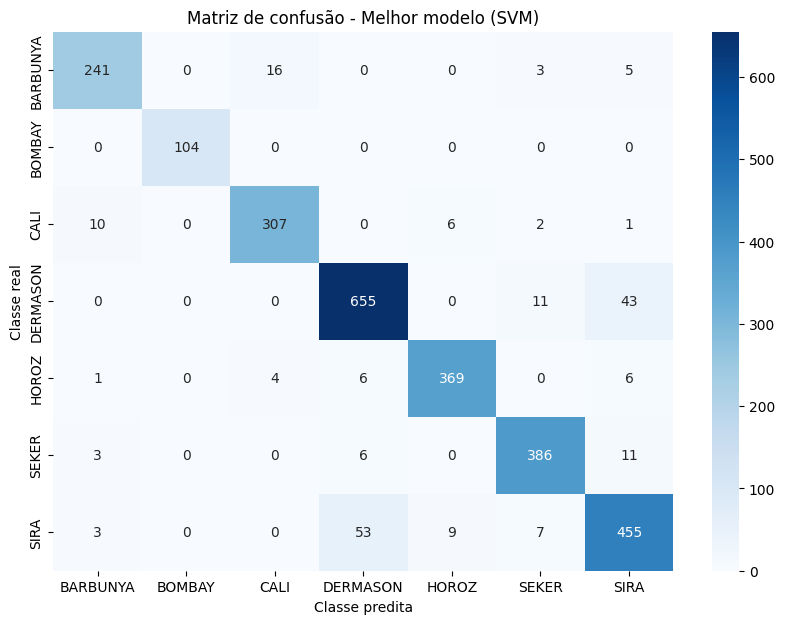

In [27]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_final_model.classes_,
    yticklabels=best_final_model.classes_
)
plt.title("Matriz de confusão - Melhor modelo (SVM)")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.show()

A avaliação detalhada do modelo SVM mostrou que ele apresentou desempenho bastante consistente no conjunto de teste. A acurácia final foi de aproximadamente 92%, enquanto o F1-score macro ficou em torno de 0,94, indicando bom equilíbrio no desempenho entre as diferentes classes.

Ao observar o relatório de classificação, nota-se que a classe `BOMBAY` teve desempenho perfeito nas métricas apresentadas, enquanto classes como `HOROZ`, `SEKER` e `CALI` também obtiveram resultados bastante elevados. A classe `SIRA` apresentou o menor desempenho relativo entre as categorias, embora ainda com resultados satisfatórios.

A matriz de confusão mostra que a maior parte das previsões corretas está concentrada na diagonal principal, o que confirma a boa capacidade de classificação do modelo. Os principais erros ocorreram em confusões entre algumas classes específicas, como `SIRA` e `DERMASON`, o que pode indicar maior semelhança entre as características dessas variedades.


## 10. Exportação do modelo final

Após a definição do melhor modelo, ele será exportado para um arquivo utilizando a biblioteca `joblib`. Essa etapa é importante para permitir a reutilização do modelo treinado na aplicação full stack, sem a necessidade de repetir todo o processo de treinamento.


In [28]:
# Exportação do melhor modelo final
joblib.dump(best_final_model, "best_dry_bean_model.joblib")

print("Modelo exportado com sucesso.")

Modelo exportado com sucesso.


## 11. Conclusão

Neste projeto, foi desenvolvido um modelo de machine learning para classificar variedades de feijão a partir de atributos físicos presentes no Dry Bean Dataset. O processo incluiu a carga dos dados por URL, análise inicial do conjunto, separação em treino e teste, aplicação de pré-processamento, treinamento de diferentes algoritmos de classificação, otimização de hiperparâmetros, avaliação dos resultados e exportação do modelo final.

Entre os modelos avaliados, o SVM apresentou o melhor desempenho, alcançando os melhores resultados de accuracy e F1-score macro após a etapa de otimização. A análise detalhada mostrou que o modelo foi capaz de classificar corretamente a maior parte das amostras, com desempenho bastante satisfatório em quase todas as classes.

De forma geral, os resultados indicam que o problema foi bem resolvido com o uso de algoritmos clássicos de machine learning e que o modelo final treinado é adequado para ser integrado a uma aplicação full stack simples para realização de predições.


## 12. Reflexão sobre boas práticas de software seguro

Embora o dataset utilizado neste projeto não contenha dados pessoais sensíveis, as boas práticas estudadas em Desenvolvimento de Software Seguro continuam sendo relevantes para a construção da solução.

Uma primeira medida importante seria a validação rigorosa dos dados de entrada recebidos pela aplicação, garantindo que apenas valores numéricos válidos e dentro de faixas esperadas sejam processados pelo modelo. Isso ajuda a evitar falhas, comportamentos inesperados e possíveis explorações da aplicação.

Outra prática importante é o controle sobre a origem e o armazenamento dos dados e do modelo treinado. Em um cenário real, seria necessário garantir a integridade do arquivo do modelo, manter versionamento adequado e restringir acessos indevidos ao back-end.

Além disso, caso o problema envolvesse dados sensíveis ou dados de pessoas, técnicas como anonimização, minimização da coleta de dados e controle de acesso deveriam ser aplicadas para reduzir riscos de exposição indevida.

Por fim, também seria recomendável registrar logs de uso da aplicação com cuidado, evitando armazenar informações desnecessárias e protegendo quaisquer dados que possam ser considerados confidenciais.
